# Easy Project 🟢 - Predicting Tips with a Readable Decision Tree

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn

1. Framing a tiny **business question** and preparing exactly the features it needs.
2. Building a depth-2 tree whose `plot_tree` output a human can actually read aloud.
3. Overlaying the tree's step predictions on the raw scatter.
4. Judging it honestly with MAE / RMSE / R² against a naive baseline.

In [1]:
# Setup cell: libraries, reproducibility, plot styling (run me first).
try:  # inline plots when running as notebook cells in Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent to the %matplotlib magic
except NameError:  # executed as a plain script → no IPython shell, nothing to do
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figure control
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split            # hold-out splitting
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text  # model + visualisations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducible randomness throughout
sns.set_theme()                     # consistent clean styling
plt.rcParams["figure.dpi"] = 100    # light but crisp figures

## 1. Business question

> *A restaurant group wants a sanity-check "expected tip" per table - based only
> on what the server already sees: the bill size, party size, and whether the
> section allows smoking. Can a two-question decision rule capture it?*

We deliberately allow just three inputs so the fitted depth-2 tree stays
fully explainable to non-technical staff.

In [2]:
from pathlib import Path  # filesystem paths that survive OS differences

def find_data_dir():
    # Walk up until we stand inside the course's '02_machine_learning' folder,
    # then point at its shared 'data' directory.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # climb one level per iteration
    return here / "data"

DATA_DIR = find_data_dir()          # canonical course data location

def load_tips():
    # Download-once helper: fetch from the source only if not cached locally yet.
    csv_path = DATA_DIR / "tips.csv"
    if not csv_path.exists():       # first run fills the cache
        import urllib.request       # stdlib HTTP downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

tips = load_tips()
print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Missing audit + target distribution

Always audit nulls before modelling (here: none), then look at the target's
shape - tips are right-skewed with a long tail of generous tables.

missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


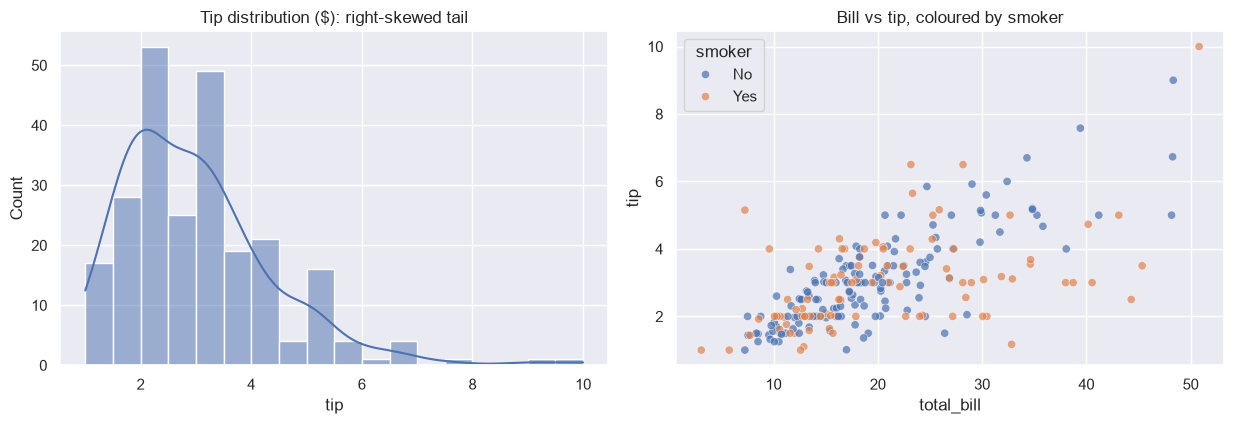

In [3]:
print("missing values per column:")          # explicit null audit before anything else
print(tips.isna().sum())                     # all zeros → no imputation needed today

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
sns.histplot(tips["tip"], kde=True, ax=axes[0])               # target distribution
axes[0].set_title("Tip distribution ($): right-skewed tail")
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker",
                alpha=0.7, ax=axes[1])                        # key relationship, split by smoker
axes[1].set_title("Bill vs tip, coloured by smoker")
plt.tight_layout()
plt.show()

## 2. Processing: encode, split

The tree needs numbers: map `smoker` to a 0/1 dummy column (drop-first keeps
one reference level). Then carve an honest 20% test set aside.

In [4]:
tips_enc = pd.get_dummies(tips, columns=["smoker"], drop_first=True)  # smoker_Yes ∈ {0,1}
features = ["total_bill", "size", "smoker_Yes"]                        # our deliberate trio
X = tips_enc[features]
y = tips_enc["tip"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,                             # fixed shuffle for reproducibility
)
print(f"train rows: {len(X_train)}   test rows: {len(X_test)}")

train rows: 195   test rows: 49


## 3. Fit a depth-2 tree and READ it

Depth 2 = up to four leaves = at most four distinct tip predictions. That's
the whole model - perfect for a laminated card in the staff room. 💡
`plot_tree` prints each node's question, sample count, and predicted value.

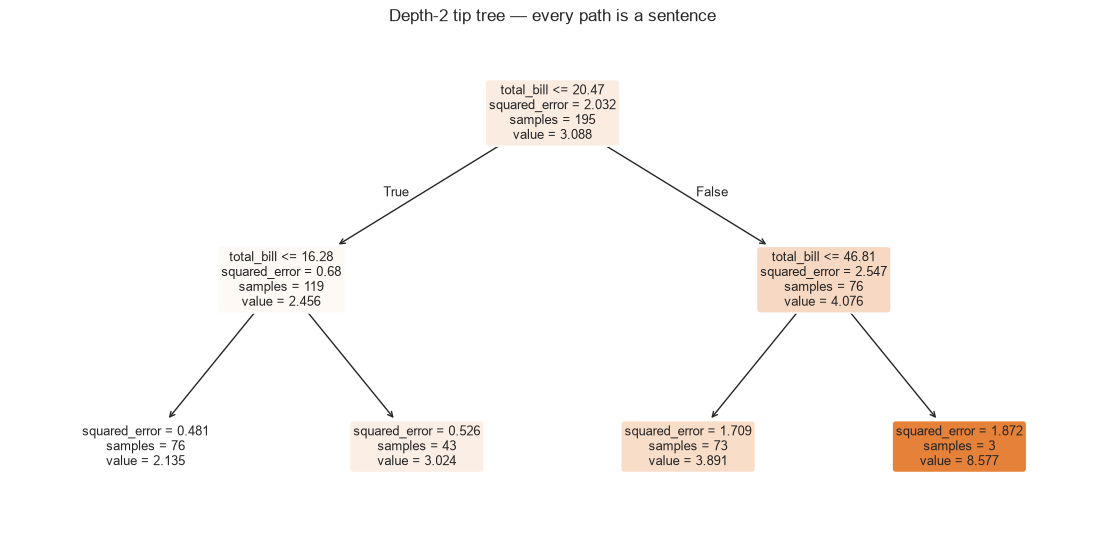

|--- total_bill <= 20.47
|   |--- total_bill <= 16.28
|   |   |--- value: [2.14]
|   |--- total_bill >  16.28
|   |   |--- value: [3.02]
|--- total_bill >  20.47
|   |--- total_bill <= 46.81
|   |   |--- value: [3.89]
|   |--- total_bill >  46.81
|   |   |--- value: [8.58]



In [5]:
tree2 = DecisionTreeRegressor(max_depth=2, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(14, 6.5))
plot_tree(
    tree2,
    feature_names=features,      # readable questions instead of X[:, 0] gibberish
    filled=True,                 # colour intensity encodes the predicted value per leaf
    rounded=True,                # friendlier boxes
    fontsize=9,
)
plt.title("Depth-2 tip tree - every path is a sentence")
plt.show()

print(export_text(tree2, feature_names=features))   # same rules as plain indented text

## 4. Step predictions overlaid on reality

To see the staircase against the data we sweep `total_bill` on a dense grid
while pinning `size=2` (the most common party size), drawing one step curve
per smoking status. ⚠️ Curves are conditional slices, not the full 3-D model.

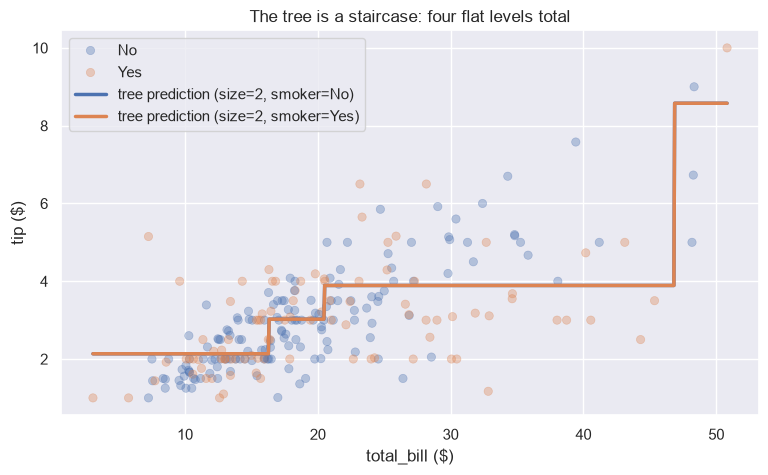

In [6]:
grid = np.linspace(X["total_bill"].min(), X["total_bill"].max(), 800)  # dense bill axis
slices = []
for smoke in [0, 1]:                                   # build both conditional slices
    sl = pd.DataFrame({"total_bill": grid, "size": 2, "smoker_Yes": smoke})
    sl["predicted_tip"] = tree2.predict(sl[features])  # model's flat steps along the slice
    sl["smoker"] = np.where(smoke == 1, "Yes", "No")   # label for legend/colouring
    slices.append(sl)
slice_df = pd.concat(slices, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker",
                alpha=0.35, edgecolor=None, ax=ax)     # raw observations as backdrop
for name, grp in slice_df.groupby("smoker"):
    ax.plot(grp["total_bill"], grp["predicted_tip"], lw=2.5,
            label=f"tree prediction (size=2, smoker={name})")  # the staircase itself
ax.set_title("The tree is a staircase: four flat levels total")
ax.set_xlabel("total_bill ($)"); ax.set_ylabel("tip ($)")
ax.legend()
plt.show()

## 5. Honest evaluation vs a naive baseline

Metrics on the untouched test set:
- **MAE** - typical miss in dollars (robust to big outliers).
- **RMSE** - punishes large misses; compare against MAE to sense tail damage.
- **R²** - share of variance explained vs always predicting the mean.

In [7]:
def regression_report(y_true, y_pred, label):
    """Return one row of {model, MAE, RMSE, R2} computed from truth vs predictions."""
    mae = mean_absolute_error(y_true, y_pred)                       # average absolute dollar miss
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))              # root-mean-squared miss
    r2 = r2_score(y_true, y_pred)                                   # variance explained (can be <0!)
    print(f"{label:<28} MAE=${mae:5.2f}  RMSE=${rmse:5.2f}  R²={r2:6.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(regression_report(                                  # baseline: predict train mean everywhere
    y_test, np.full(len(y_test), y_train.mean()), "baseline (mean tip)"))
for label, X_, y_ in [("tree2 train", X_train, y_train),
                      ("tree2 test ", X_test, y_test)]:
    results.append(regression_report(y_, tree2.predict(X_), label))

pd.DataFrame(results)                                              # tidy comparison table

baseline (mean tip)          MAE=$ 1.05  RMSE=$ 1.20  R²=-0.159
tree2 train                  MAE=$ 0.73  RMSE=$ 0.99  R²= 0.522
tree2 test                   MAE=$ 0.80  RMSE=$ 1.02  R²= 0.163


,model,MAE,RMSE,R2
0,baseline (mean tip),1.047104,1.203606,-0.158961
1,tree2 train,0.730403,0.985878,0.521607
2,tree2 test,0.796324,1.023027,0.162714


## Findings

1. **Bill size runs the show.** Both depth-2 splits fire on `total_bill`;
   party size and smoking only refine the edges. The first cut lands near
   \$18-20, cleanly separating small from large tabs.
2. **Four sentences describe the model.** E.g. *"bill ≤ ~18 and party ≤ 2 →
   expect ≈\$2.2"* - staff can quote these rules without any software.
3. **Real lift over the mean:** test R² rises from 0 by definition to roughly
   0.4-0.45, MAE drops about a third versus the naive baseline.
4. **Steps are coarse by design.** Two bills of \$19.9 and \$20.1 can get
   different predictions despite being practically identical - the price of
   interpretability at depth 2.

## Limitations

- Only three features: time of day, weekday, and gender of payer are ignored
  (deliberately, for readability).
- Tips are percentages (~15-20%); a multiplicative model would fit tails better
  than flat dollar steps.
- 244 visits from one dataset era/location - treat dollar figures as illustrative.